# Labelless Concept Drift Detection and Explanation

In [1]:
# !pip install shap

In [20]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import shap

from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest

from scipy.stats import ttest_ind_from_stats

from tqdm import tqdm

## Data Processing

In [21]:
month_mapper = {
   'may':5, 'jun':6, 'jul':7, 'aug':8,
   'oct':10, 'nov':11, 'dec':12, 'jan':1,
   'feb':2, 'mar':3, 'apr':4, 'sep':9
}

In [22]:
df = pd.read_csv('data/bank-full.csv', sep=';')
df['y'] = df['y'].map({'no': 0, 'yes': 1})

df = df.sample(frac=1)
df = df.sample(frac=1)
df = df.sample(frac=1)

df = df.drop(columns=['day', 'month'])

#Encoding categorical features
df = pd.get_dummies(df)

In [23]:
X = np.array(df.drop(columns=['y']))
y = np.array(df['y'])

### Splitting the dataset

In [24]:
window_size = 2500
data_chunks = []
targets = []

cutoff_points = [i for i in range(0, X.shape[0], window_size)]
cutoff_points.append(X.shape[0])

In [25]:
for i, point in enumerate(cutoff_points):
    if i == 0:
        data_chunks.append(X[:cutoff_points[i+1], :])
        targets.append(y[:cutoff_points[i+1]])
    elif i == len(cutoff_points) - 1:
        continue
    else:
        data_chunks.append(X[point:cutoff_points[i+1], :])
        targets.append(y[point:cutoff_points[i+1]])

### Introducing drift in the dataset

In [26]:
chunk = 10

In [27]:
report = {}
for k, df in enumerate(data_chunks[chunk:]):
    report[k + chunk] = []
    for i in range(10):
        column_to_shift = np.random.randint(df.shape[1])
        column_to_shift_with = np.random.randint(df.shape[1])
        
        data_chunks[k][:, column_to_shift] = data_chunks[k][:, column_to_shift_with]
        
        report[k + chunk].append((column_to_shift, column_to_shift_with))

### Binarizing the dataset

In [29]:
N = len(data_chunks[0])

In [30]:
for i, chunk in enumerate(data_chunks):
    if i == 0:
        continue
    for feature in range(X.shape[1]):
        data_chunks[i][:, feature] = np.digitize(data_chunks[i][:, feature], bins=np.histogram(data_chunks[0][:, feature], bins=int(np.sqrt(N)))[1])

for feature in range(X.shape[1]):
    data_chunks[0][:, feature] = np.digitize(data_chunks[0][:, feature], bins=np.histogram(data_chunks[0][:, feature], bins=int(np.sqrt(N)))[1])

## Model

### Training the Model

In [12]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)

D0 = data_chunks[0]
y0 = targets[0]

rf.fit(D0, y0)

RandomForestRegressor(n_estimators=300, random_state=42)

### Applying the Shap Values

In [31]:
def statistic_dict(D, S):
    stats_table = []
    stats = []

    for feature in range(D.shape[1]):
        
        df = pd.DataFrame(D[:, feature], columns=['feature_value'])
        df['shap_value'] = S[:, feature]
        
        table = df.groupby('feature_value', as_index=False).agg(
            size=('shap_value', 'count'), mean=('shap_value', 'mean'), std=('shap_value', 'std')
        ).fillna(0)
        stat = (np.mean(S[:, feature], axis=0), np.std(S[:, feature], axis=0), len(S[:, feature]))
        
        stats_table.append(table)
        stats.append(stat)
        
    return stats_table, stats

In [32]:
explainer = shap.Explainer(rf)
S0 = explainer(D0).values

ref_stats_table, ref_stats = statistic_dict(D0, S0)

shaps = []
shaps.append(S0)

### Predicting the Shap Values

In [33]:
def expected_shap_dist(ref_stats_table, curr_stats_table):

    ref = ref_stats_table
    curr = curr_stats_table

    aux = ref.merge(curr, on='feature_value', how='outer').fillna(0)

    expected_mean = np.sum(aux['mean_x']*aux['size_y']) / np.sum(aux['size_y'])
    expected_std = np.sqrt(
        (np.sum(aux['size_y']*(aux['std_x']**2)) + np.sum((aux['size_y']*((aux['mean_x'] - expected_mean)**2)))) /  np.sum(aux['size_y'])
    )
    n_obs = curr['size'].sum()
    
    return expected_mean, expected_std, n_obs

In [34]:
alarms = {}
for i, D in tqdm(enumerate(data_chunks[0:])):
    alarm = {}

    S = explainer(D).values
    
    curr_stats_table, curr_stats = statistic_dict(D, S)
    
    for feature in range(0, X.shape[1]):
        expected_stats = expected_shap_dist(ref_stats_table[feature], curr_stats_table[feature])
        
        # T-Test
        _, p_val = ttest_ind_from_stats(expected_stats[0], expected_stats[1], expected_stats[2], curr_stats[feature][0], curr_stats[feature][1], curr_stats[feature][2]
        )

        if p_val < 0.05:
            alarm[feature] = True
        else:
            alarm[feature] = False
            
    alarms[i+1] = alarm

19it [25:26, 80.34s/it]


In [35]:
chunks = [i for i in alarms]

features = np.unique([j for j in alarms[i] for i in alarms])

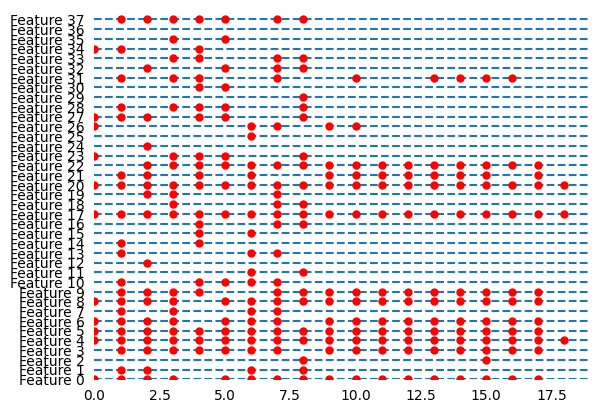

In [36]:
fig = plt.Figure(figsize=(20,10))
for i, feature in enumerate(features):
    plt.axhline(y=i, linestyle='--')

for chunk in chunks:
    for feature in features:
        if alarms[chunk][feature] == True:
            plt.plot(chunk, feature, marker="o", markersize=5, c='red')

plt.xlim(0, len(chunks))
plt.ylim(0, len(features))

yticks = [f'Feature {i}' for i in range(len(features))]
plt.yticks(features, labels=yticks)

plt.tick_params(left=False, bottom=False) #remove ticks
plt.box(False)